In [1]:
# Step 1: Import Libraries
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.utils import to_categorical

In [2]:
# Step 3: Display Dataset Shape
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
print("Training Data Shape :", x_train.shape)
print("Testing Data Shape  :", x_test.shape)

Training Data Shape : (60000, 28, 28)
Testing Data Shape  : (10000, 28, 28)


In [3]:
# Step 4: Normalize the Data
x_train = x_train / 255.0
x_test = x_test / 255.0

In [4]:
# Step 5: Class Labels
class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]

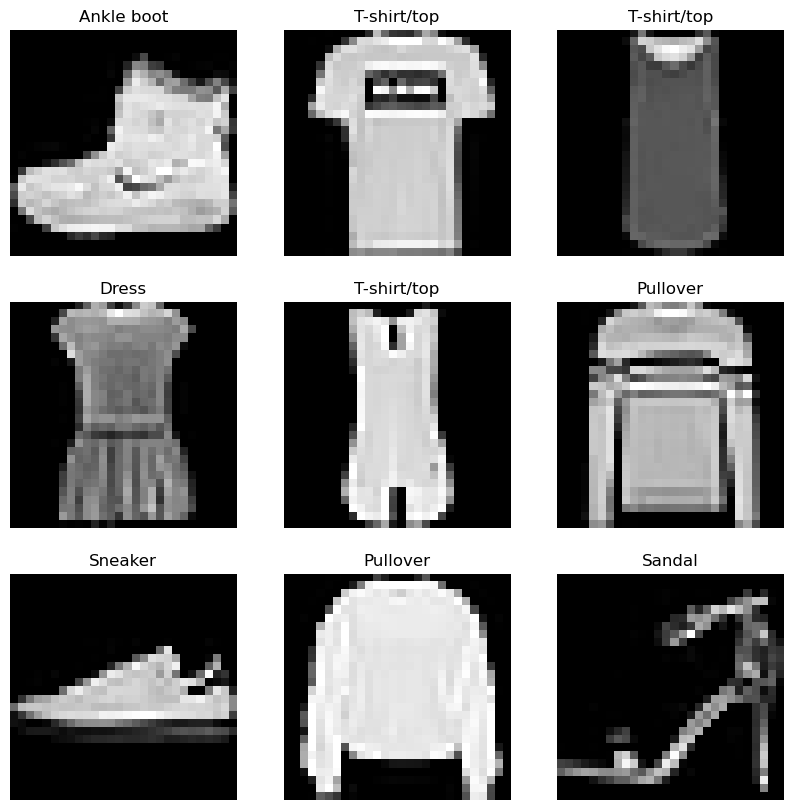

In [5]:
# Step 6: Display Sample Images
plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')

plt.show()

In [6]:
# Step 7: Build Deep Neural Network Model
model = Sequential([
    Flatten(input_shape=(28,28)),
    
    Dense(128, activation='relu'),
    Dense(64, activation='relu'),
    
    Dense(10, activation='softmax')
])


c:\Users\vishw\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [7]:
# Step 8: Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [8]:
# Step 9: Train Model
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8182 - loss: 0.5117 - val_accuracy: 0.8525 - val_loss: 0.4125
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8627 - loss: 0.3732 - val_accuracy: 0.8680 - val_loss: 0.3562
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8738 - loss: 0.3418 - val_accuracy: 0.8621 - val_loss: 0.3726
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8820 - loss: 0.3154 - val_accuracy: 0.8766 - val_loss: 0.3414
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8892 - loss: 0.2956 - val_accuracy: 0.8791 - val_loss: 0.3388
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8944 - loss: 0.2828 - val_accuracy: 0.8833 - val_loss: 0.3261
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8981 - loss: 0.2677 - val_accuracy: 0.8780 - val_loss: 0.3467
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9041 - loss: 0.2566 

In [9]:
# Step 10: Evaluate Model
test_loss, test_accuracy = model.evaluate(x_test, y_test)

print("\nTest Accuracy :", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8803 - loss: 0.3477

Test Accuracy : 0.880299985408783


In [10]:
# Step 11: Predict on Test Data
predictions = model.predict(x_test)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


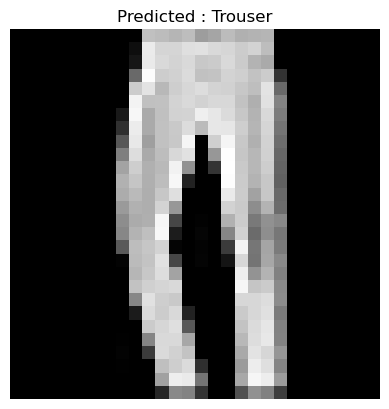

Actual Label    : Trouser
Predicted Label : Trouser


In [11]:
# Step 12: Show Prediction Example
index = 5

plt.imshow(x_test[index], cmap='gray')
plt.title("Predicted : " + class_names[np.argmax(predictions[index])])
plt.axis('off')
plt.show()

print("Actual Label    :", class_names[y_test[index]])
print("Predicted Label :", class_names[np.argmax(predictions[index])])

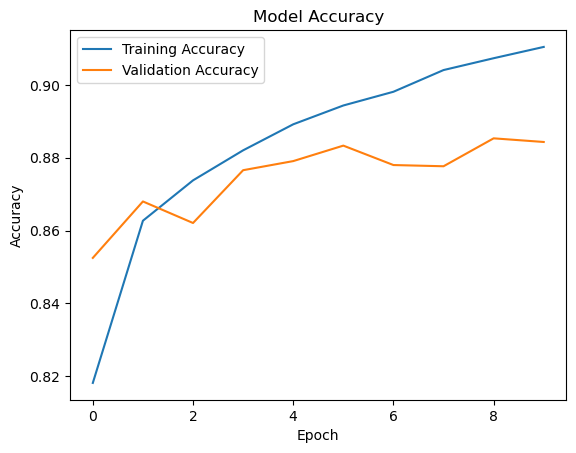

In [12]:
# Step 13: Plot Accuracy Graph
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend(['Training Accuracy', 'Validation Accuracy'])

plt.show()

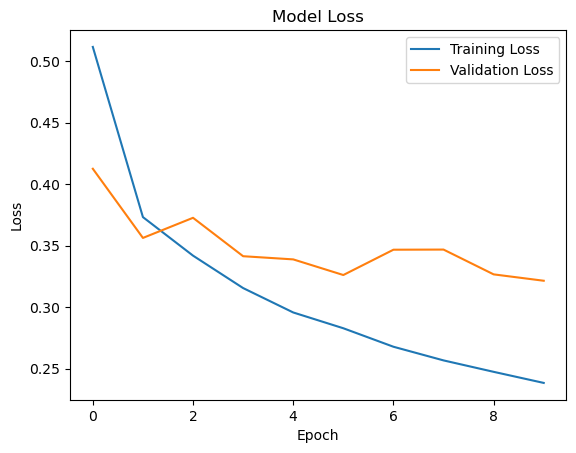

In [13]:
# Step 14: Plot Loss Graph
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend(['Training Loss', 'Validation Loss'])

plt.show()